<a href="https://colab.research.google.com/github/yeoauqt/TB_Clustering/blob/main/TB_Clustering_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
Uploaded=files.upload()

Saving TB_Dataset_encode_clus.xlsx to TB_Dataset_encode_clus.xlsx


In [ ]:
import os
import pandas as pd

In [ ]:
df = pd.read_excel('TB_Dataset_encode_clus.xlsx')

df.head()

,BMI,Gender,Age,ICD10_Group_Chronic_Diseases,ICD10_Group_Lymph_Node_TB,ICD10_Group_Miliary_TB,ICD10_Group_Nervous_System_TB,ICD10_Group_Other_Extrapulmonary_TB,ICD10_Group_Other_Respiratory_TB,ICD10_Group_Pulmonary_TB,...,Take a Co-Trimoxazole,(TB F/U) follow up,position of TB,Chronic Kidney Disease,Chronic Obstructive Pulmonary Disease,Diabetes Mellitus,Liver Disease,AFB resulf of first month,Duration,result
0,15.23,0,68,0,0,0,0,0,0,1,...,0,1,1,0,0,0,0,3,1.0,เสียชีวิต
1,23.11,1,41,0,0,0,0,0,0,1,...,0,3,2,0,0,0,0,0,6.0,รักษาครบ
2,21.45,0,42,0,0,0,0,0,0,1,...,0,1,1,0,0,0,0,-1,6.0,รักษาครบ
3,17.57,1,45,0,0,0,0,0,0,1,...,0,3,1,0,0,1,0,2,6.0,รักษาหาย
4,19.12,0,21,0,0,0,0,0,0,1,...,0,2,1,0,0,0,0,2,6.0,รักษาหาย


In [ ]:
# แสดงจำนวนแถว
print("Number of rows:", len(df))

Number of rows: 25239


In [ ]:
# แสดงชื่อคอลัมน์ทั้งหมด
print("Columns:", df.columns.tolist())

Columns: ['BMI', 'Gender', 'Age', 'ICD10_Group_Chronic_Diseases', 'ICD10_Group_Lymph_Node_TB', 'ICD10_Group_Miliary_TB', 'ICD10_Group_Nervous_System_TB', 'ICD10_Group_Other_Extrapulmonary_TB', 'ICD10_Group_Other_Respiratory_TB', 'ICD10_Group_Pulmonary_TB', 'ICD10_Group_Unspecified_TB', 'Patients Register Types', 'Cohort of TB', 'HIV', 'Treatment of ARV', 'Take a Co-Trimoxazole', '(TB F/U) follow up', 'position of TB', 'Chronic Kidney Disease', ' Chronic Obstructive Pulmonary Disease', 'Diabetes Mellitus', 'Liver Disease', ' AFB resulf of first month', 'Duration', 'result']


In [ ]:
# ดูจำนวน label
df['result'].value_counts()

,count
result,
รักษาครบ,9765
รักษาหาย,9037
เสียชีวิต,3199
เปลี่ยนวินิจฉัย,1304
ขาดยา,752
กำลังรักษา,669
โอนออก,297
RR/MDR ก่อนเดือนที่ 5,138
ล้มเหลว,78


In [ ]:
# show data train
print('number of rows :',df.shape[0])
print('number of columns :',df.shape[1])
df.info()
df.head()

# นำออกข้อมูล train
df.to_csv('traindata.csv',index=False)

number of rows : 25239
number of columns : 25
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25239 entries, 0 to 25238
Data columns (total 25 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   BMI                                     25239 non-null  float64
 1   Gender                                  25239 non-null  int64  
 2   Age                                     25239 non-null  int64  
 3   ICD10_Group_Chronic_Diseases            25239 non-null  int64  
 4   ICD10_Group_Lymph_Node_TB               25239 non-null  int64  
 5   ICD10_Group_Miliary_TB                  25239 non-null  int64  
 6   ICD10_Group_Nervous_System_TB           25239 non-null  int64  
 7   ICD10_Group_Other_Extrapulmonary_TB     25239 non-null  int64  
 8   ICD10_Group_Other_Respiratory_TB        25239 non-null  int64  
 9   ICD10_Group_Pulmonary_TB                25239 non-null  int64  
 10  ICD10_Group_

In [ ]:
# เช็คจำนวนและเปอร์เซ็นต์ของ Missing Values ในแต่ละคอลัมน์
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

# นำมารวมกันเป็น DataFrame เพื่อให้อ่านง่าย
missing_report = pd.DataFrame({
    'Missing Count': missing_data,
    'Percentage (%)': missing_percent
}).sort_values(by='Missing Count', ascending=False)

# แสดงเฉพาะคอลัมน์ที่มี Missing Values
print("--- Missing Values Report ---")
print(missing_report[missing_report['Missing Count'] > 0])

--- Missing Values Report ---
          Missing Count  Percentage (%)
Duration           1479        5.859979


In [ ]:
def clean_data(df, name="Dataset"):
    print(f"--- Cleaning Report for: {name} ---")
    # 2. เช็คและลบ Missing Values (เปลี่ยนจาก ffill/bfill เป็น dropna)
    missing_rows = df.isnull().any(axis=1).sum()
    if missing_rows > 0:
        print(f"[!] Found {missing_rows} rows with missing values. Dropping them...")
        df = df.dropna()
    else:
        print("[✓] No missing values found.")

    # 3. ลบ Constant Columns
    constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
    if len(constant_cols) > 0:
        print(f"[*] Removing {len(constant_cols)} constant columns: {constant_cols}")
        df = df.drop(columns=constant_cols)
    else:
        print("[✓] No constant columns to remove.")

    print(f"Final shape: {df.shape}\n")
    return df


In [ ]:
dt_after_clean = clean_data(df)

--- Cleaning Report for: Dataset ---
[!] Found 1479 rows with missing values. Dropping them...
[✓] No constant columns to remove.
Final shape: (23760, 25)



In [ ]:
# ดูจำนวน label
dt_after_clean['result'].value_counts()

,count
result,
รักษาครบ,9570
รักษาหาย,8749
เสียชีวิต,2920
เปลี่ยนวินิจฉัย,1255
ขาดยา,725
โอนออก,283
RR/MDR ก่อนเดือนที่ 5,126
ล้มเหลว,75
กำลังรักษา,57


In [ ]:
df_after_clean = dt_after_clean[~dt_after_clean['result'].isin(['โอนออก','กำลังรักษา'])]

In [ ]:
print(df_after_clean['result'].value_counts())

result
รักษาครบ                 9570
รักษาหาย                 8749
เสียชีวิต                2920
เปลี่ยนวินิจฉัย          1255
ขาดยา                     725
RR/MDR ก่อนเดือนที่ 5     126
ล้มเหลว                    75
Name: count, dtype: int64


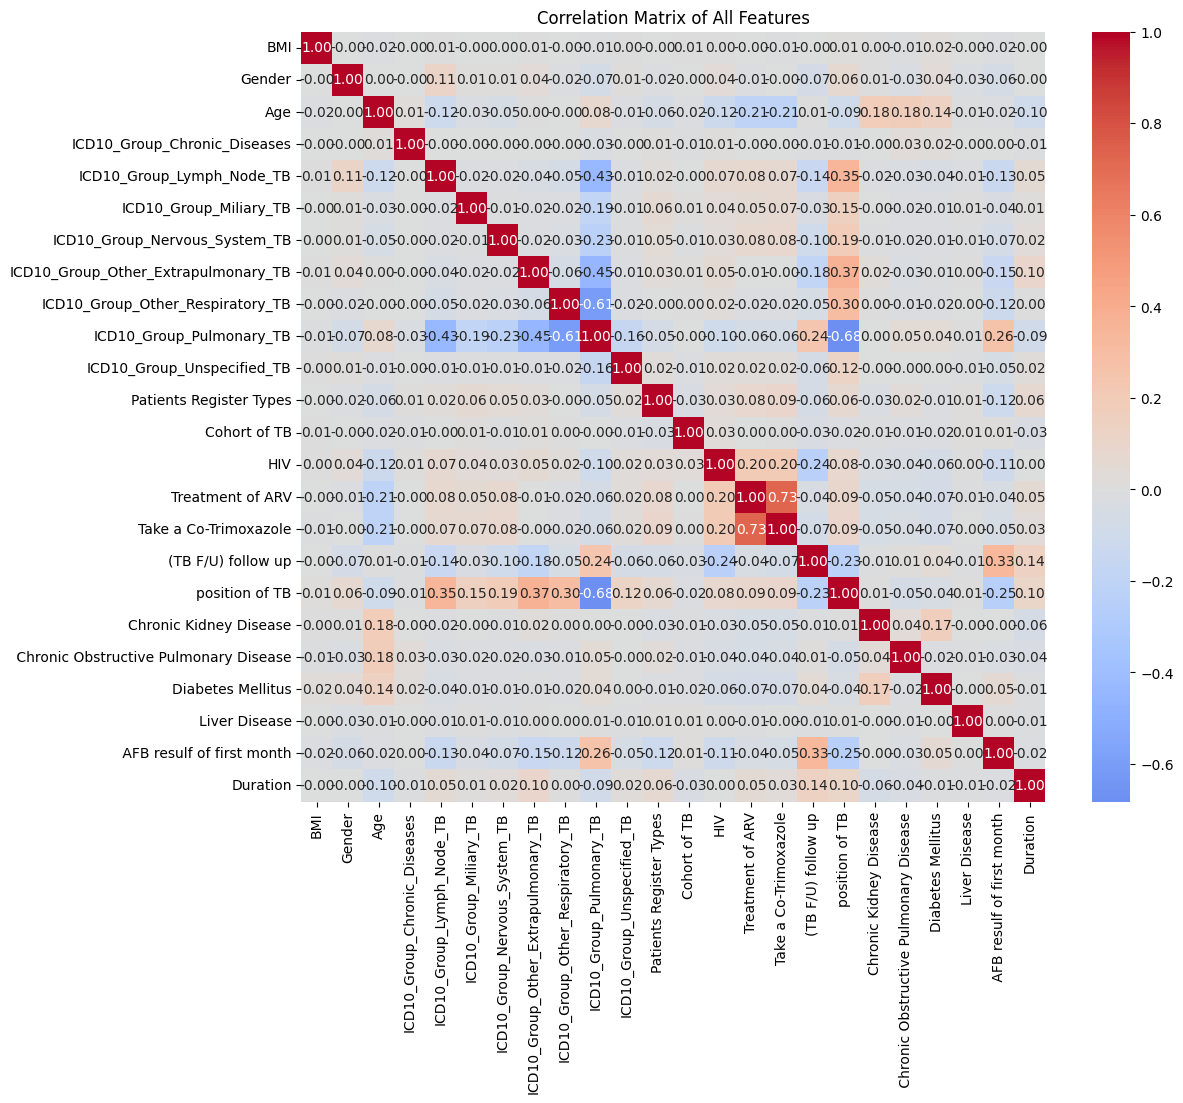

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns for correlation calculation
corr_matrix = dt_after_clean.select_dtypes(include=['number']).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix of All Features')
plt.show()

# PHASE **1**

STEP 1 : สร้าง Target

In [ ]:
def create_target(x):

    if x in ['รักษาหาย', 'รักษาครบ']:
        return 0

    elif x in ['เสียชีวิต', 'ขาดยา', 'เปลี่ยนวินิจฉัย', 'ล้มเหลว', 'RR/MDR ก่อนเดือนที่ 5 ']:
        return 1

    else:
        return None

In [ ]:
df_after_clean['target'] = df_after_clean['result'].apply(create_target)

df_after_clean = df_after_clean[df_after_clean['target'].notna()]

/tmp/ipykernel_8120/2427547002.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_after_clean['target'] = df_after_clean['result'].apply(create_target)


In [ ]:
df_after_clean

,BMI,Gender,Age,ICD10_Group_Chronic_Diseases,ICD10_Group_Lymph_Node_TB,ICD10_Group_Miliary_TB,ICD10_Group_Nervous_System_TB,ICD10_Group_Other_Extrapulmonary_TB,ICD10_Group_Other_Respiratory_TB,ICD10_Group_Pulmonary_TB,...,(TB F/U) follow up,position of TB,Chronic Kidney Disease,Chronic Obstructive Pulmonary Disease,Diabetes Mellitus,Liver Disease,AFB resulf of first month,Duration,result,target
0,15.23,0,68,0,0,0,0,0,0,1,...,1,1,0,0,0,0,3,1.0,เสียชีวิต,1.0
1,23.11,1,41,0,0,0,0,0,0,1,...,3,2,0,0,0,0,0,6.0,รักษาครบ,0.0
2,21.45,0,42,0,0,0,0,0,0,1,...,1,1,0,0,0,0,-1,6.0,รักษาครบ,0.0
3,17.57,1,45,0,0,0,0,0,0,1,...,3,1,0,0,1,0,2,6.0,รักษาหาย,0.0
4,19.12,0,21,0,0,0,0,0,0,1,...,2,1,0,0,0,0,2,6.0,รักษาหาย,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25231,17.09,0,67,0,0,0,0,0,0,1,...,3,1,0,0,0,0,3,8.0,รักษาหาย,0.0
25232,21.48,0,56,0,0,0,0,0,0,1,...,2,2,0,0,0,0,-1,0.0,รักษาหาย,0.0
25233,21.09,0,64,0,0,0,0,0,1,0,...,3,2,0,1,0,0,0,5.0,รักษาครบ,0.0
25237,17.33,0,58,0,0,0,0,0,0,1,...,1,1,0,0,0,0,0,8.0,รักษาครบ,0.0


In [ ]:
df_after_clean.columns

Index(['BMI', 'Gender', 'Age', 'ICD10_Group_Chronic_Diseases',
       'ICD10_Group_Lymph_Node_TB', 'ICD10_Group_Miliary_TB',
       'ICD10_Group_Nervous_System_TB', 'ICD10_Group_Other_Extrapulmonary_TB',
       'ICD10_Group_Other_Respiratory_TB', 'ICD10_Group_Pulmonary_TB',
       'ICD10_Group_Unspecified_TB', 'Patients Register Types', 'Cohort of TB',
       'HIV', 'Treatment of ARV', 'Take a Co-Trimoxazole',
       '(TB F/U) follow up', 'position of TB', 'Chronic Kidney Disease',
       ' Chronic Obstructive Pulmonary Disease', 'Diabetes Mellitus',
       'Liver Disease', ' AFB resulf of first month', 'Duration', 'result',
       'target'],
      dtype='object')

STEP 2 : สร้าง X Y

In [ ]:
selected_columns = [('BMI', 'Gender', 'Age', 'ICD10_Group_Chronic_Diseases',
       'ICD10_Group_Lymph_Node_TB', 'ICD10_Group_Miliary_TB',
       'ICD10_Group_Nervous_System_TB', 'ICD10_Group_Other_Extrapulmonary_TB',
       'ICD10_Group_Other_Respiratory_TB', 'ICD10_Group_Pulmonary_TB',
       'ICD10_Group_Unspecified_TB', 'Patients Register Types', 'Cohort of TB',
       'HIV', 'Treatment of ARV', 'Take a Co-Trimoxazole',
       '(TB F/U) follow up', 'position of TB', 'Chronic Kidney Disease',
       ' Chronic Obstructive Pulmonary Disease', 'Diabetes Mellitus',
       'Liver Disease', ' AFB resulf of first month', 'Duration')]

In [ ]:
X = df_after_clean[list(selected_columns[0])]
y = df_after_clean['target']

In [ ]:
X

,BMI,Gender,Age,ICD10_Group_Chronic_Diseases,ICD10_Group_Lymph_Node_TB,ICD10_Group_Miliary_TB,ICD10_Group_Nervous_System_TB,ICD10_Group_Other_Extrapulmonary_TB,ICD10_Group_Other_Respiratory_TB,ICD10_Group_Pulmonary_TB,...,Treatment of ARV,Take a Co-Trimoxazole,(TB F/U) follow up,position of TB,Chronic Kidney Disease,Chronic Obstructive Pulmonary Disease,Diabetes Mellitus,Liver Disease,AFB resulf of first month,Duration
0,15.23,0,68,0,0,0,0,0,0,1,...,0,0,1,1,0,0,0,0,3,1.0
1,23.11,1,41,0,0,0,0,0,0,1,...,0,0,3,2,0,0,0,0,0,6.0
2,21.45,0,42,0,0,0,0,0,0,1,...,0,0,1,1,0,0,0,0,-1,6.0
3,17.57,1,45,0,0,0,0,0,0,1,...,0,0,3,1,0,0,1,0,2,6.0
4,19.12,0,21,0,0,0,0,0,0,1,...,0,0,2,1,0,0,0,0,2,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25231,17.09,0,67,0,0,0,0,0,0,1,...,0,0,3,1,0,0,0,0,3,8.0
25232,21.48,0,56,0,0,0,0,0,0,1,...,0,0,2,2,0,0,0,0,-1,0.0
25233,21.09,0,64,0,0,0,0,0,1,0,...,0,0,3,2,0,1,0,0,0,5.0
25237,17.33,0,58,0,0,0,0,0,0,1,...,0,0,1,1,0,0,0,0,0,8.0


In [ ]:
y

,target
0,1.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
25231,0.0
25232,0.0
25233,0.0
25237,0.0


STEP 3 : Split train and test

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

STEP 4 : Train XG

In [ ]:
from xgboost import XGBClassifier

# กำหนดโมเดล XGBoost พร้อมกับพารามิเตอร์ที่ดีที่สุดที่หามาได้
best_xgb = XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=3.6821608040201004,
    random_state=42,
    subsample=0.9,
    n_estimators=300,
    max_depth=3,
    learning_rate=0.01,
    colsample_bytree=0.8
)

# ทำการเทรนโมเดล
best_xgb.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import classification_report
y_pred_xgb_tuned = best_xgb.predict(X_test)
print(classification_report(y_test, y_pred_xgb_tuned))

              precision    recall  f1-score   support

         0.0       0.95      0.97      0.96      3664
         1.0       0.89      0.82      0.85       995

    accuracy                           0.94      4659
   macro avg       0.92      0.90      0.91      4659
weighted avg       0.94      0.94      0.94      4659



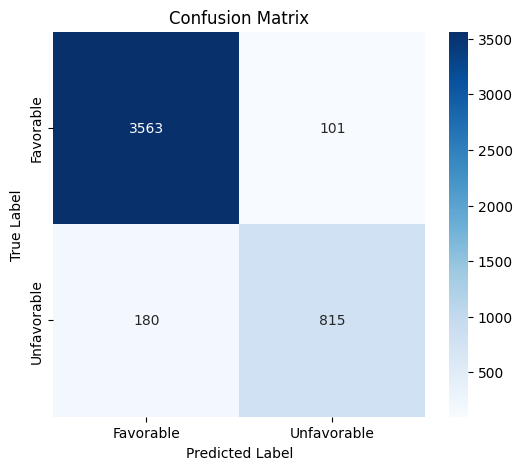

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# สร้าง confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb_tuned)

# plot
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Favorable', 'Unfavorable'],
    yticklabels=['Favorable', 'Unfavorable']
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()

STEP 4 : Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

best_rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_estimators=100,
    min_samples_split=2,
    min_samples_leaf=4,
    max_depth=5
)

# ทำการเทรนโมเดล
best_rf.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=5, min_samples_leaf=4,
                       random_state=42)

In [ ]:
y_pred_rf_tuned = best_rf.predict(X_test)
print(classification_report(y_test, y_pred_rf_tuned))

              precision    recall  f1-score   support

         0.0       0.95      0.97      0.96      3664
         1.0       0.88      0.82      0.85       995

    accuracy                           0.94      4659
   macro avg       0.92      0.90      0.91      4659
weighted avg       0.94      0.94      0.94      4659



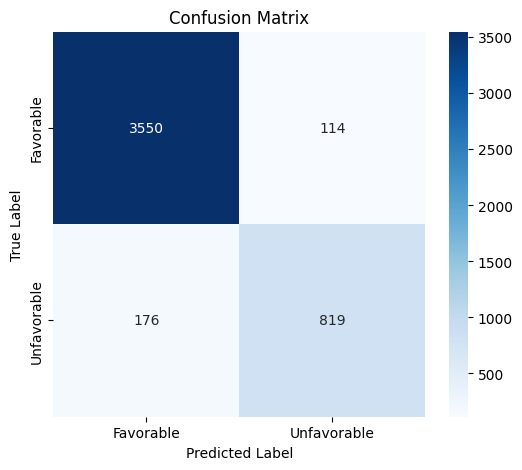

Random Forest test Accuracy: 93.78


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

cm_ran = confusion_matrix(y_test, y_pred_rf_tuned)
plt.figure(figsize=(6,5))
sns.heatmap(cm_ran, annot=True, fmt='d', cmap="Blues", xticklabels=['Favorable', 'Unfavorable'], yticklabels=['Favorable', 'Unfavorable'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

accuracy = accuracy_score(y_test, y_pred_rf_tuned) * 100
print(f"Random Forest test Accuracy: {accuracy:.2f}")

STEP 4 : catboost

In [ ]:
!
!pip install catboost
from catboost import CatBoostClassifier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.2 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostClassifier

best_cat = CatBoostClassifier(
    auto_class_weights='Balanced',
    verbose=False,
    random_state=42,
    learning_rate=0.01,
    l2_leaf_reg=3,
    iterations=200,
    depth=10
)

# ทำการเทรนโมเดล
best_cat.fit(X_train, y_train)


CatBoostClassifier(auto_class_weights='Balanced', depth=10, iterations=200, l2_leaf_reg=3, learning_rate=0.01, random_state=42, verbose=False)

In [ ]:
best_cat = cat_random.best_estimator_
y_pred_cat_tuned = best_cat.predict(X_test)
print(classification_report(y_test, y_pred_cat_tuned))

              precision    recall  f1-score   support

         0.0       0.95      0.97      0.96      3664
         1.0       0.89      0.82      0.85       995

    accuracy                           0.94      4659
   macro avg       0.92      0.90      0.91      4659
weighted avg       0.94      0.94      0.94      4659



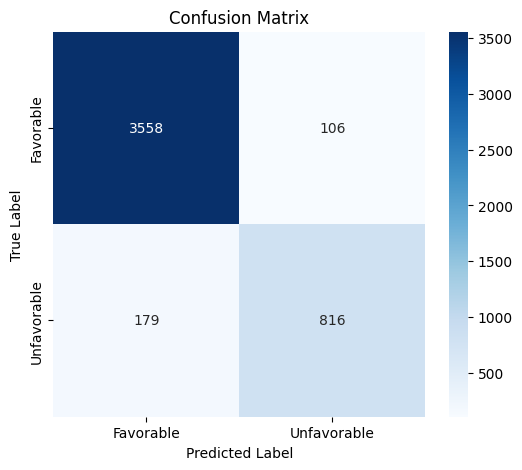

Random Forest test Accuracy: 93.88


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

cm_ran = confusion_matrix(y_test, y_pred_cat_tuned)
plt.figure(figsize=(6,5))
sns.heatmap(cm_ran, annot=True, fmt='d', cmap="Blues", xticklabels=['Favorable', 'Unfavorable'], yticklabels=['Favorable', 'Unfavorable'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

accuracy = accuracy_score(y_test, y_pred_cat_tuned) * 100
print(f"Random Forest test Accuracy: {accuracy:.2f}")

STEP 4 : Train ANN model

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(
    X_train,
    y_train
)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# model = Sequential([
#     Dense(64, activation='relu', input_shape=(X_train_sm.shape[1],)),
#     Dense(32, activation='relu'),
#     Dense(1, activation='sigmoid')
# ])

model_ANN = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_ANN.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model_ANN.fit(
    X_train_sm,
    y_train_sm,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    class_weight={0:1, 1:3}
)

Epoch 1/50
733/733 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7200 - loss: 0.8864 - val_accuracy: 0.7909 - val_loss: 0.2822
Epoch 2/50
733/733 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8454 - loss: 0.6163 - val_accuracy: 0.8439 - val_loss: 0.2206
Epoch 3/50
733/733 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8475 - loss: 0.5905 - val_accuracy: 0.9058 - val_loss: 0.1582
Epoch 4/50
733/733 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8512 - loss: 0.5484 - val_accuracy: 0.9277 - val_loss: 0.1609
Epoch 5/50
733/733 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8544 - loss: 0.5198 - val_accuracy: 0.9017 - val_loss: 0.1463
Epoch 6/50
733/733 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8583 - loss: 0.5299 - val_accuracy: 0.9065 - val_loss: 0.1655
Epoch 7/50
733/733 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8590 - loss: 0.5120 - val_accuracy: 0.9092 - val_loss: 0.1689
Epoch 8/50
733/733 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8646 - loss: 0.5062 - val_accuracy: 0.

In [ ]:
loss, acc = model.evaluate(X_test, y_test)

In [ ]:
# predict
y_prob = model_ANN.predict(X_test)
y_pred_ANN = (y_prob > 0.70).astype(int)

# ดูผล
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(confusion_matrix(y_test, y_pred_ANN))

print(classification_report(y_test, y_pred_ANN))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[3486  178]
 [ 170  825]]
              precision    recall  f1-score   support

         0.0       0.95      0.95      0.95      3664
         1.0       0.82      0.83      0.83       995

    accuracy                           0.93      4659
   macro avg       0.89      0.89      0.89      4659
weighted avg       0.93      0.93      0.93      4659

ROC-AUC: 0.9435575804788133


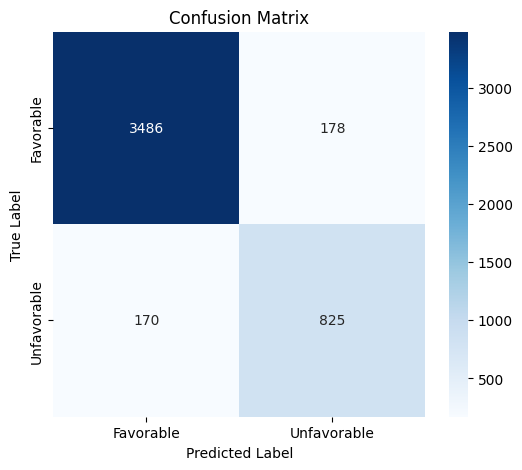

Random Forest test Accuracy: 92.53


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

cm_ran = confusion_matrix(y_test, y_pred_ANN)
plt.figure(figsize=(6,5))
sns.heatmap(cm_ran, annot=True, fmt='d', cmap="Blues", xticklabels=['Favorable', 'Unfavorable'], yticklabels=['Favorable', 'Unfavorable'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

accuracy = accuracy_score(y_test, y_pred_ANN) * 100
print(f"Random Forest test Accuracy: {accuracy:.2f}")

STEP 5 : Evalution

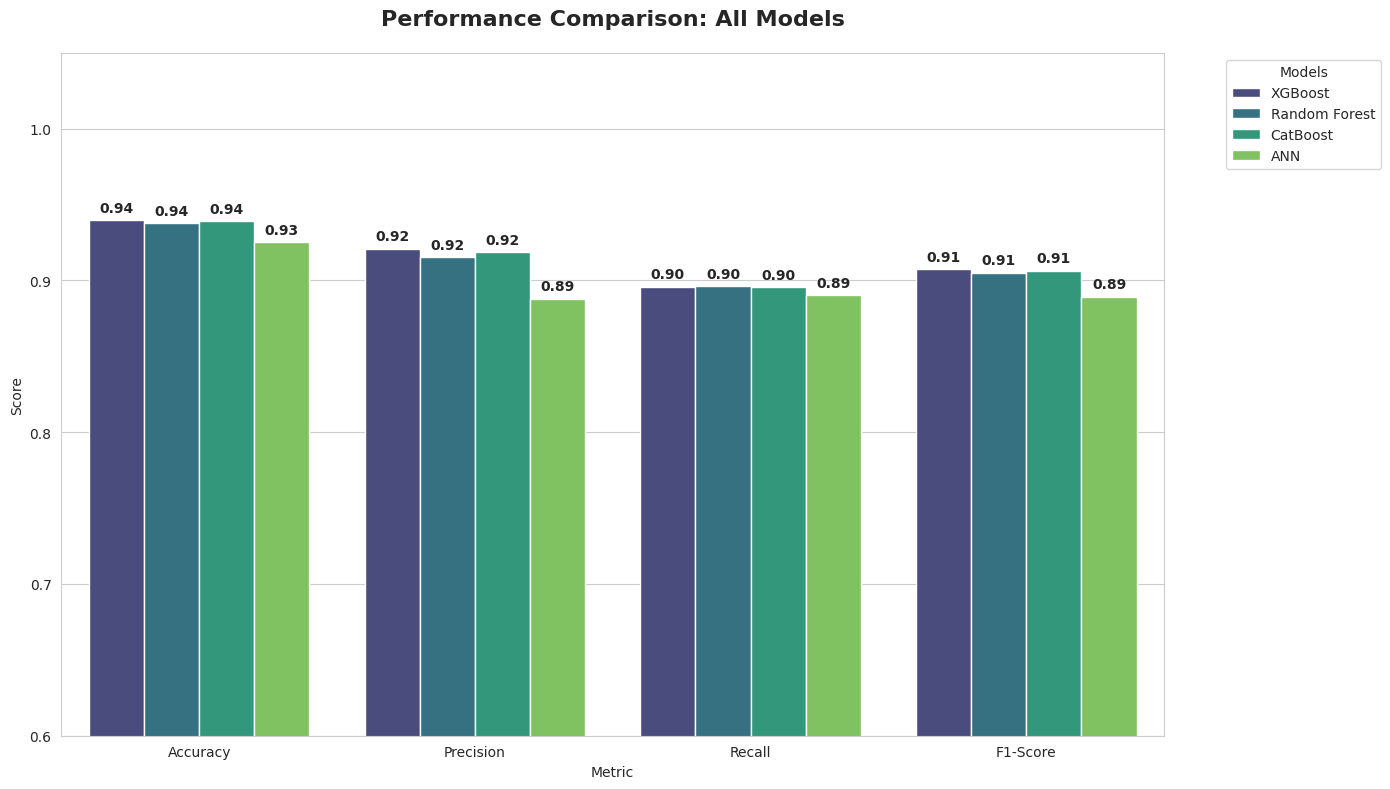


--- Summary Table ---
        Model  Accuracy  Precision   Recall  F1-Score
      XGBoost  0.939687   0.920824 0.895765  0.907510
Random Forest  0.937755   0.915289 0.896001  0.905171
     CatBoost  0.938828   0.918567 0.895585  0.906411
          ANN  0.925306   0.888017 0.890282  0.889142


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

# 1. รวบรวมข้อมูล Prediction ของทุกโมเดล
models = {
    'XGBoost': y_pred_xgb_tuned,
    'Random Forest': y_pred_rf_tuned,
    'CatBoost': y_pred_cat_tuned,
    'ANN': y_pred_ANN
}

# 2. วนลูปเพื่อดึงค่า Macro Avg (Precision, Recall, F1, Accuracy) ออกมาอัตโนมัติ
summary_list = []

for name, y_pred in models.items():
    # ดึง report ออกมาเป็น dictionary
    report = classification_report(y_test, y_pred, output_dict=True)

    summary_list.append({
        'Model': name,
        'Accuracy': report['accuracy'],
        'Precision': report['macro avg']['precision'],
        'Recall': report['macro avg']['recall'],
        'F1-Score': report['macro avg']['f1-score']
    })

# 3. สร้าง DataFrame
df_compare = pd.DataFrame(summary_list)

# 4. แปลงข้อมูลเป็น Long-form สำหรับวาดกราฟ
df_melted = df_compare.melt(id_vars='Model', var_name='Metric', value_name='Score')

# 5. วาดกราฟ
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

ax = sns.barplot(data=df_melted, x='Metric', y='Score', hue='Model', palette='viridis')

# ตกแต่งกราฟ
plt.title('Performance Comparison: All Models', fontsize=16, fontweight='bold', pad=20)
plt.ylim(0.6, 1.05) # ปรับตามความเหมาะสมของคะแนนคุณ
plt.ylabel('Score')

# ใส่ตัวเลขบนหัวเสา
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(format(p.get_height(), '.2f'),
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha = 'center', va = 'center',
                    xytext = (0, 9),
                    textcoords = 'offset points',
                    fontsize=10, fontweight='bold')

plt.legend(title='Models', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# แถม: แสดงตารางสรุป
print("\n--- Summary Table ---")
print(df_compare.to_string(index=False))

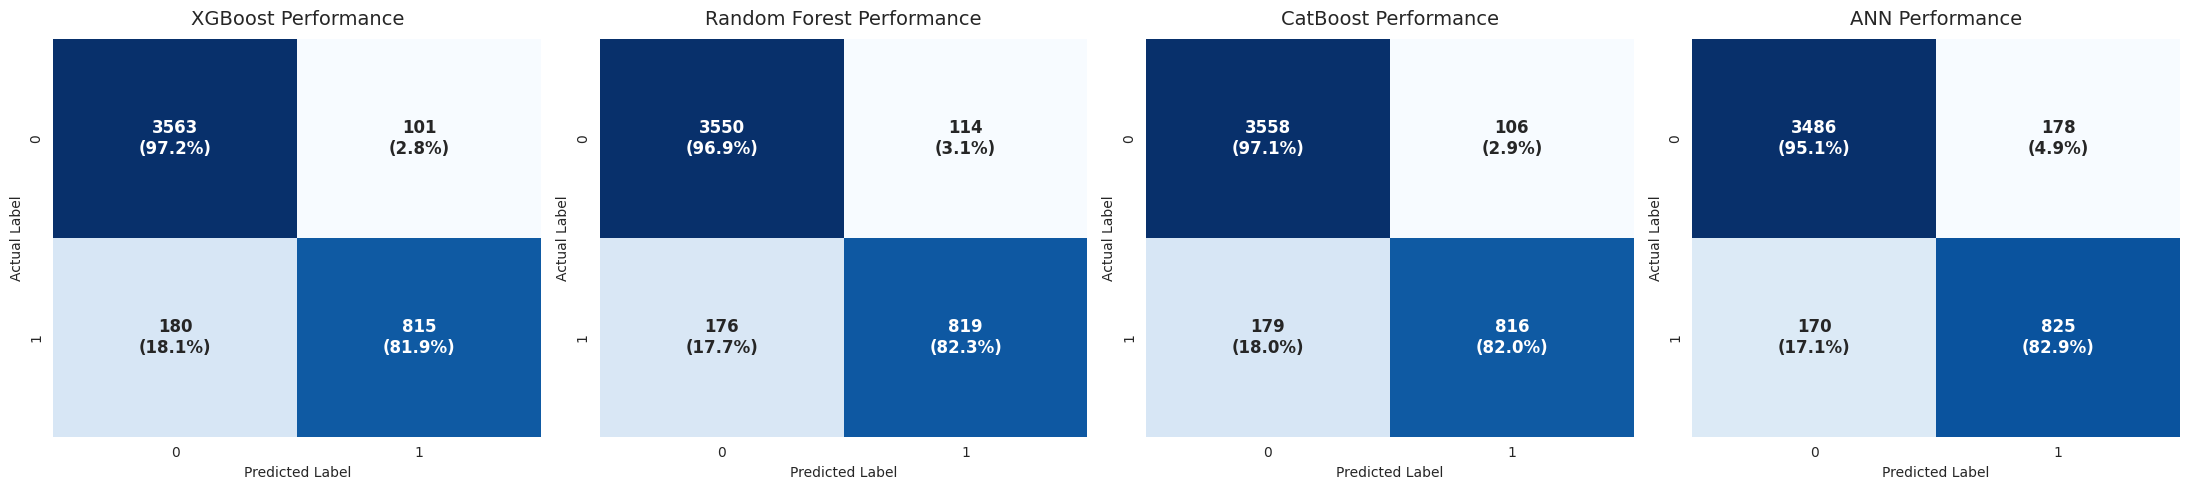

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_sub_confusion_matrix_dual(y_true, y_pred, title, ax):
    # 1. คำนวณเมทริกซ์แบบจำนวนจริง (Original)
    cm = confusion_matrix(y_true, y_pred)

    # 2. คำนวณเมทริกซ์แบบเปอร์เซ็นต์ (Normalization ตามแนวแถว/Actual)
    cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    # 3. สร้าง Label ที่รวมทั้ง จำนวนจริง และ เปอร์เซ็นต์ เข้าด้วยกัน
    # รูปแบบคือ: "จำนวนจริง\n(เปอร์เซ็นต์%)"
    labels = (np.array(["{0:d}\n({1:.1f}%)".format(count, perc)
              for count, perc in zip(cm.flatten(), cm_perc.flatten())]
             )).reshape(2, 2)

    # 4. วาด Heatmap โดยใช้ cm_perc เป็นตัวกำหนดสี แต่ใช้ labels เป็นตัวเลขแสดงผล
    sns.heatmap(cm_perc, annot=labels, fmt='', cmap='Blues', ax=ax, cbar=False,
                annot_kws={"size": 12, "weight": "bold"})

    ax.set_title(title, fontsize=14, pad=10)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('Actual Label')

# สร้างพื้นที่สำหรับ 4 กราฟ (1 แถว 4 คอลัมน์)
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# รันฟังก์ชันสำหรับแต่ละโมเดล
plot_sub_confusion_matrix_dual(y_test, y_pred_xgb_tuned, 'XGBoost Performance', axes[0])
plot_sub_confusion_matrix_dual(y_test, y_pred_rf_tuned, 'Random Forest Performance', axes[1])
plot_sub_confusion_matrix_dual(y_test, y_pred_cat_tuned, 'CatBoost Performance', axes[2])
plot_sub_confusion_matrix_dual(y_test, y_pred_ANN, 'ANN Performance', axes[3])

plt.tight_layout()
plt.show()

146/146 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


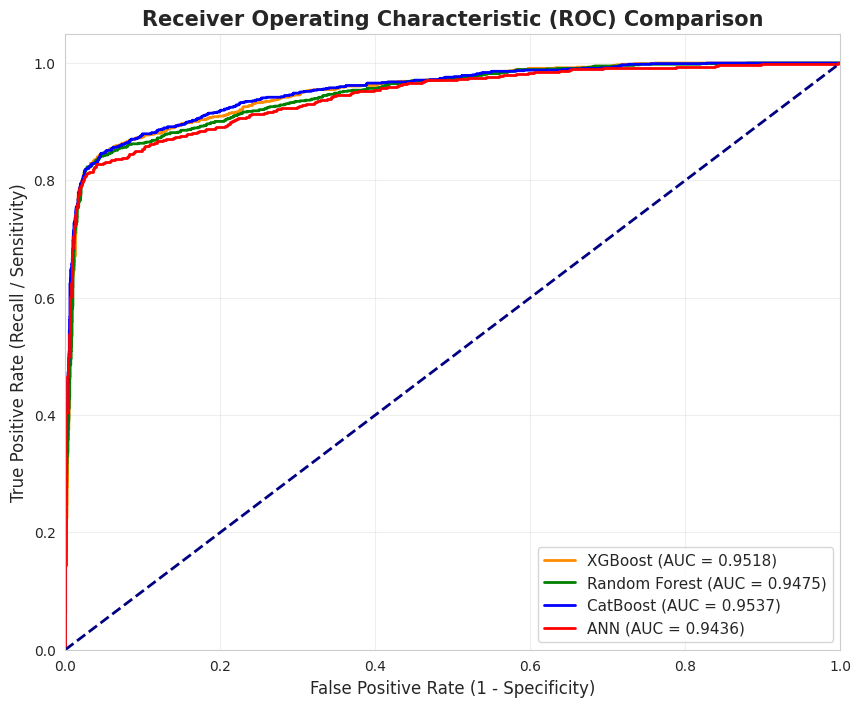

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. คำนวณค่า Probability ของคลาส 1 สำหรับแต่ละโมเดล
# หมายเหตุ: สำหรับ ANN ถ้าใช้ sigmoid ใน layer สุดท้ายให้ใช้ y_pred_ANN_prob ได้เลย
# แต่ถ้าใช้ตระกูล Tree ต้องใช้ .predict_proba()[:, 1]
probs = {
    'XGBoost': best_xgb.predict_proba(X_test)[:, 1],
    'Random Forest': best_rf.predict_proba(X_test)[:, 1],
    'CatBoost': best_cat.predict_proba(X_test)[:, 1],
    'ANN': model_ANN.predict(X_test).ravel()
}

plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")

# สีสำหรับแต่ละเส้น
colors = ['darkorange', 'green', 'blue', 'red']
model_names = list(probs.keys())

# 2. วนลูปเพื่อคำนวณ ROC และ AUC แล้วพล็อตกราฟ
for i, name in enumerate(model_names):
    fpr, tpr, _ = roc_curve(y_test, probs[name])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f'{name} (AUC = {roc_auc:.4f})')

# 3. ลากเส้นตรงกลาง (Random Classifier Line)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# 4. ตกแต่งกราฟ
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall / Sensitivity)', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Comparison', fontsize=15, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)

plt.show()

146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3588 (\N{THAI CHARACTER KHO KHWAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3649 (\N{THAI CHARACTER SARA AE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, *

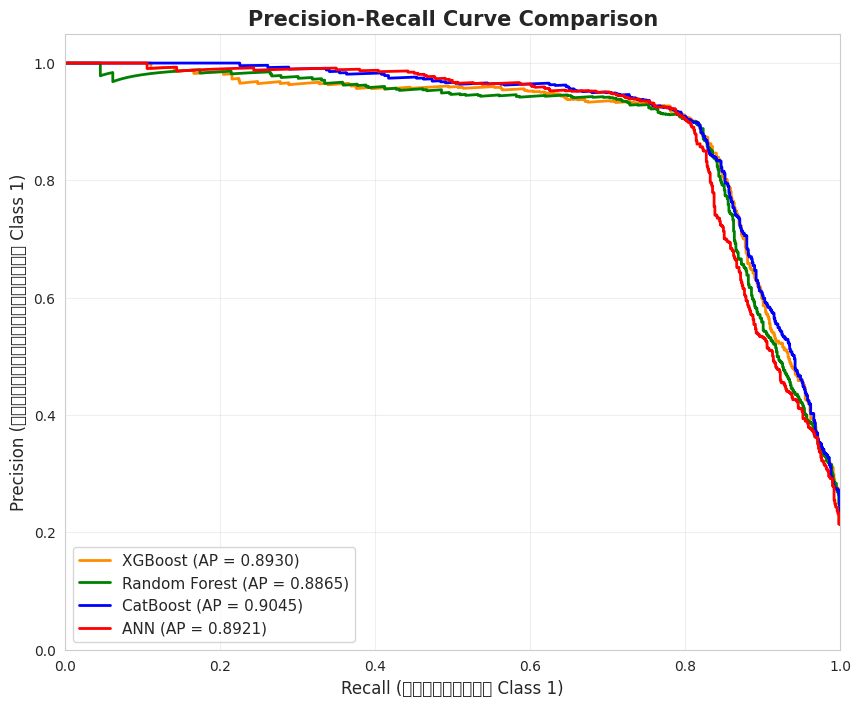

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# 1. เตรียมค่า Probability ของคลาส 1
# หมายเหตุ: สำหรับ ANN ปรับตามรูปทรง output ของคุณ (เช่น .ravel())
probs = {
    'XGBoost': best_xgb.predict_proba(X_test)[:, 1],
    'Random Forest': best_rf.predict_proba(X_test)[:, 1],
    'CatBoost': best_cat.predict_proba(X_test)[:, 1],
    'ANN': model_ANN.predict(X_test).ravel()
}

plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")

colors = ['darkorange', 'green', 'blue', 'red']
model_names = list(probs.keys())

# 2. วนลูปคำนวณ Precision, Recall และ Average Precision (AP)
for i, name in enumerate(model_names):
    precision, recall, _ = precision_recall_curve(y_test, probs[name])
    ap_score = average_precision_score(y_test, probs[name])

    plt.plot(recall, precision, color=colors[i], lw=2,
             label=f'{name} (AP = {ap_score:.4f})')

# 3. ตกแต่งกราฟ
plt.xlabel('Recall (การดักจับ Class 1)', fontsize=12)
plt.ylabel('Precision (ความแม่นยำในการทาย Class 1)', fontsize=12)
plt.title('Precision-Recall Curve Comparison', fontsize=15, fontweight='bold')
plt.legend(loc="lower left", fontsize=11)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(alpha=0.3)

plt.show()

/tmp/ipykernel_8120/858444484.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Model', y='Error_Rate (%)', data=df_compare, palette='Reds_r')


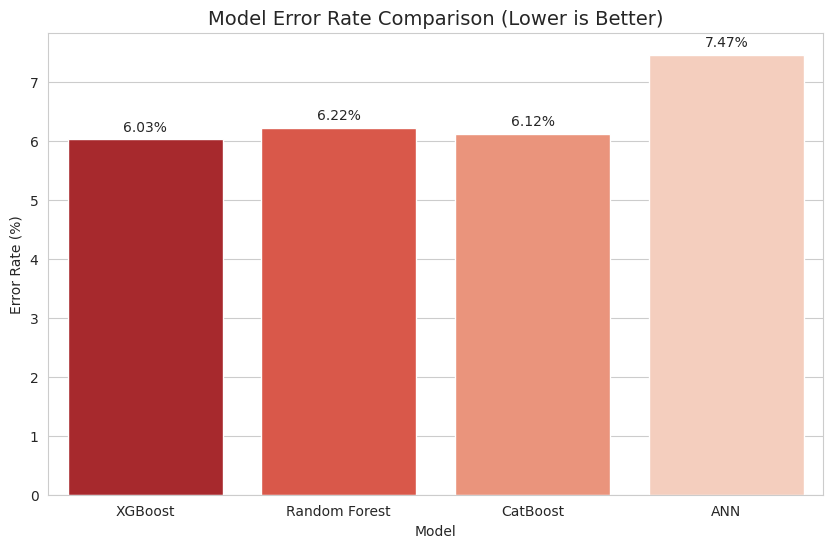

In [ ]:
# คำนวณ Error Rate (%)
df_compare['Error_Rate (%)'] = (1 - df_compare['Accuracy']) * 100

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Model', y='Error_Rate (%)', data=df_compare, palette='Reds_r')

plt.title('Model Error Rate Comparison (Lower is Better)', fontsize=14)
plt.ylabel('Error Rate (%)')

# ใส่เปอร์เซ็นต์บนหัวเสา
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.show()